In [1]:
import os, json

In [2]:
script_path = os.getcwd()
project_path = os.path.join(script_path, '..')
validation_results_dir = os.path.join(project_path, 'data', 'validation_results')
val_results_path = os.path.join(validation_results_dir, 'validation_results_content_relevance_score.json')

In [3]:
with open(val_results_path, "r", encoding="utf-8") as f:
    val_results = json.load(f)

In [4]:
val_results

{'feature_name': 'content_relevance_score',
 'feature_type': 'ordinal',
 'individual_validation': {'score_type': 'accuracy',
  'validation_threshold': 0.8,
  'score_value': [0.6808510638297872, 0.6170212765957447, 0.6595744680851063],
  'validation_passed': [False, False, False]},
 'global_validation': {'validation_threshold': 0.8,
  'prob_validation_passed': 0.0,
  'validation_passed': False},
 'llm_metadata': {'model_name': 'gpt-4o-mini',
  'temperature': 0.0,
  'iterations_predicted_values': {'npna0go': [5, 5, 5],
   'ndtbue3': [5, 5, 4],
   'm7udrrz': [1, 1, 1],
   'numrc1o': [1, 1, 1],
   'nr2x8zf': [4, 5, 4],
   'mpryire': [3, 3, 3],
   'nqbq4pj': [4, 4, 4],
   'mpfgslv': [2, 3, 2],
   'm85ycus': [3, 3, 3],
   'nj58xc5': [3, 3, 3],
   'm6xjxzs': [5, 5, 5],
   'm9o54rs': [3, 2, 2],
   'nku4zpn': [0, 0, 0],
   'mvt89sa': [3, 3, 3],
   'mlt428q': [5, 5, 3],
   'mua93jn': [5, 4, 5],
   'niztq3p': [3, 3, 3],
   'n7ojbyg': [5, 4, 5],
   'nol83wb': [4, 4, 4],
   'nmf1v4n': [4, 4, 4],
  

---

### **Features Generation Validation Analysis: variability and accuracy of the predictions**

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import sys 
sys.path.insert(0, project_path)
from src.feature_engineering_utils import load_labeled_sample

labeling_dir = os.path.join(project_path, 'data', 'labeled_samples')
val_sample_path = os.path.join(labeling_dir, '03a_validation_sample.json')
df_val = load_labeled_sample(val_sample_path)

iter_pred_values_dict = val_results['llm_metadata']['iterations_predicted_values']
iter_pred_values_df_wide = pl.DataFrame(iter_pred_values_dict)

comment_ids = list(iter_pred_values_dict.keys())
predicted_values = list(iter_pred_values_dict.values())
iter_pred_values_df_long = pl.DataFrame({'comment_id': comment_ids, 'predicted_values': predicted_values})

feature_name = 'content_relevance_score'
true_values_df = df_val[['comment_id', feature_name]]

true_predicted_values_df = true_values_df.join(
    iter_pred_values_df_long, on='comment_id', how='inner'
).with_columns(
    predicted_values_mean = pl.col('predicted_values').list.mean(),
    predicted_values_std = pl.col('predicted_values').list.std(),
    predicted_values_q25 = pl.col('predicted_values').list.eval(pl.element().quantile(0.25)).list.first(),
    predicted_values_q75 = pl.col('predicted_values').list.eval(pl.element().quantile(0.75)).list.first(),
    predicted_values_range = 5 - 0 # Theoretical range 
    # predicted_values_range = pl.col('predicted_values').list.max() - pl.col('predicted_values').list.min() # Observed range
).with_columns(
    predicted_values_cv_std = (pl.col('predicted_values_std') / pl.col('predicted_values_mean').abs()).fill_nan(None),
    predicted_values_cv_quantiles = ((pl.col('predicted_values_q75') - pl.col('predicted_values_q25')) / (pl.col('predicted_values_q75') + pl.col('predicted_values_q25'))).fill_nan(None),
    predicted_values_cv_range = (pl.col('predicted_values_std') / pl.col('predicted_values_range')).fill_nan(None)
).sort(
    by='predicted_values_mean'
)

df_plot = iter_pred_values_df_wide.unpivot(
    variable_name="comment_id", 
    value_name="prediction"
).sort(
    by='prediction'
).join(true_values_df, on='comment_id', how='inner'
).join(true_predicted_values_df[['comment_id', 'predicted_values_mean', 'predicted_values_std']], on='comment_id', how='inner'
)

In [62]:
true_predicted_values_df['predicted_values_cv_std'].mean()

0.07423443756351407

In [63]:
true_predicted_values_df['predicted_values_cv_quantiles'].mean() 

0.017054263565891473

In [64]:
true_predicted_values_df['predicted_values_cv_range'].mean()

0.03685214484189101

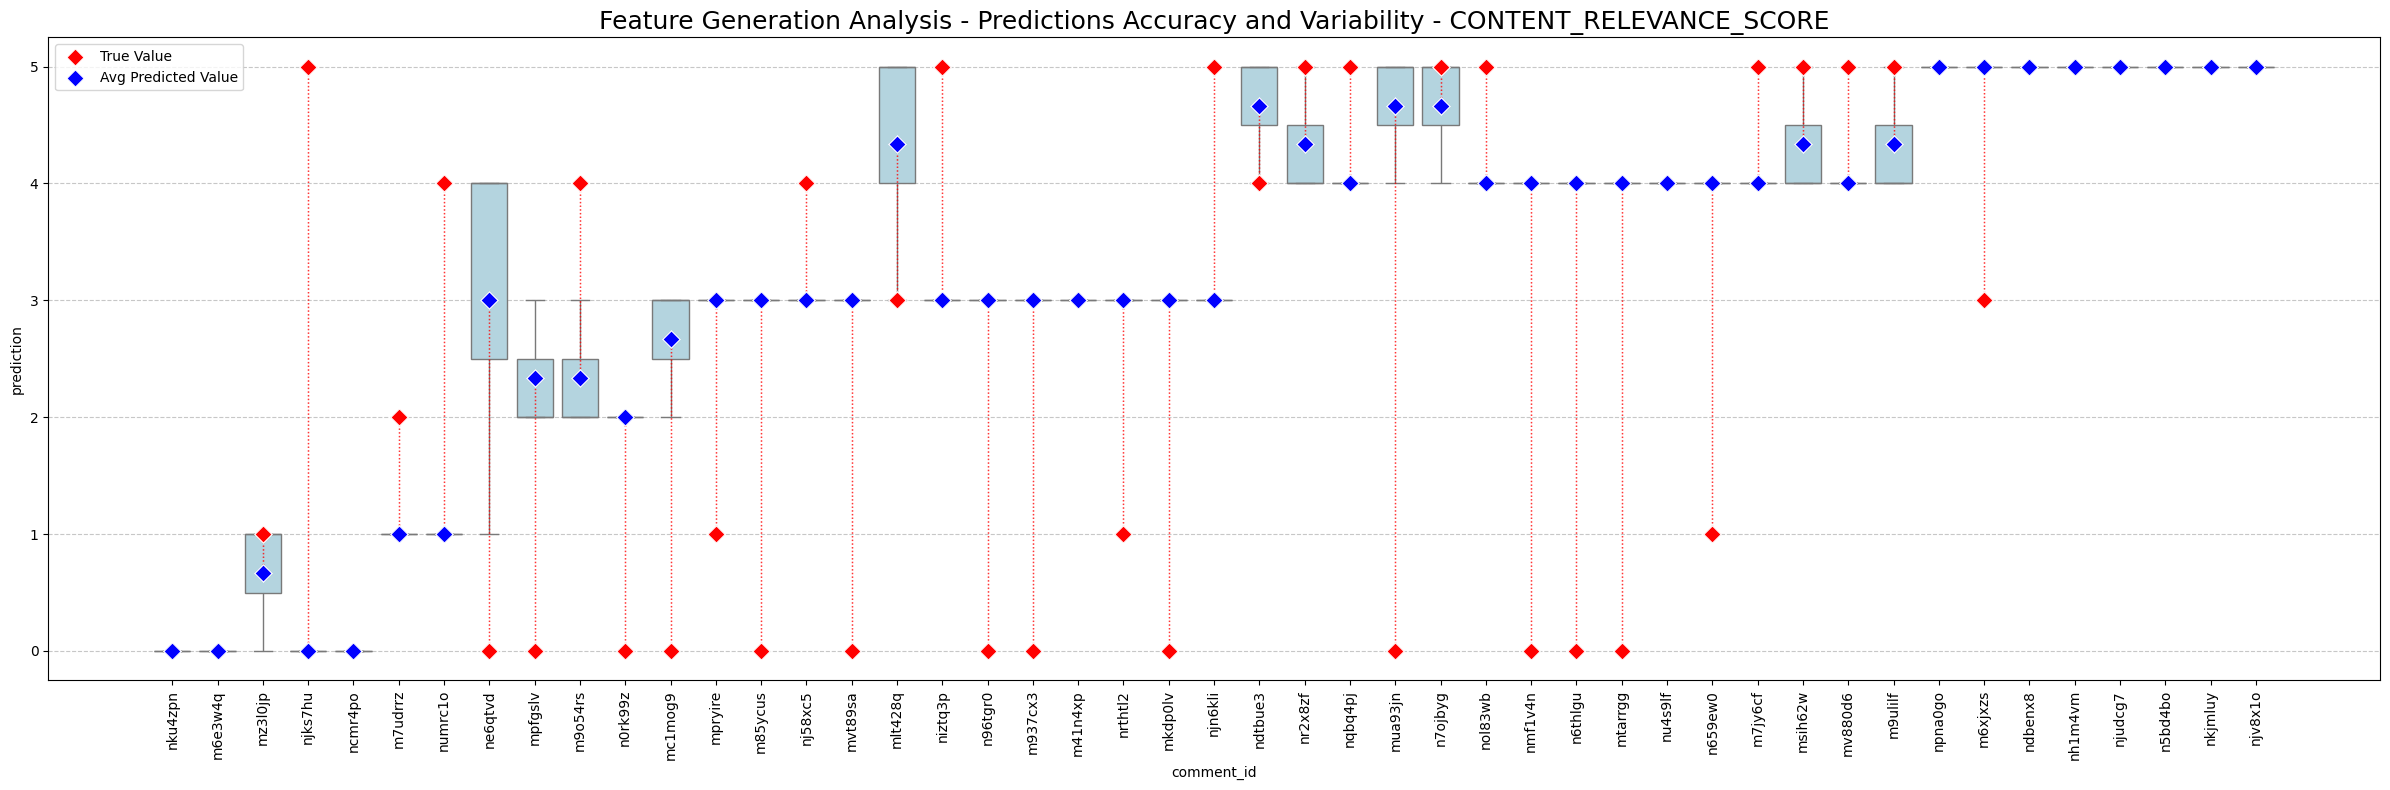

In [68]:
plt.figure(figsize=(24, 8))

# A. Boxplot de las Predicciones (Ordenado)
sns.boxplot(
    data=df_plot,
    x="comment_id",
    y="prediction",
    color="lightblue",
    showfliers=True
)

# C. "Ground Truth" (El valor real - PUNTO ROJO)
sns.scatterplot(
    data=df_plot,
    x="comment_id",
    y=feature_name,
    color="red",
    s=75,            # Tamaño grande
    marker="D",       # Forma de diamante
    label="True Value",
    zorder=10         # Para que aparezca encima de todo
)

sns.scatterplot(
    data=df_plot,
    x="comment_id",
    y="predicted_values_mean",
    color="blue",
    s=75,            # Tamaño grande
    marker="D",       # Forma de diamante
    label="Avg Predicted Value",
    zorder=10         # Para que aparezca encima de todo
)

plt.vlines(
    x=df_plot["comment_id"],
    ymin=df_plot[feature_name],
    ymax=df_plot["predicted_values_mean"],
    colors='red',
    linestyles='dotted',
    alpha=0.4,
    linewidth=1,
    label='Residual Error'
)

plt.title(f"Feature Generation Analysis - Predictions Accuracy and Variability - {feature_name.upper()}", fontsize=18)
plt.xticks(rotation=90, fontsize=10) # Rotar etiquetas 90 grados
plt.grid(axis='y', linestyle='--', alpha=0.7) # Rejilla horizontal para ver mejor los niveles
plt.tight_layout()

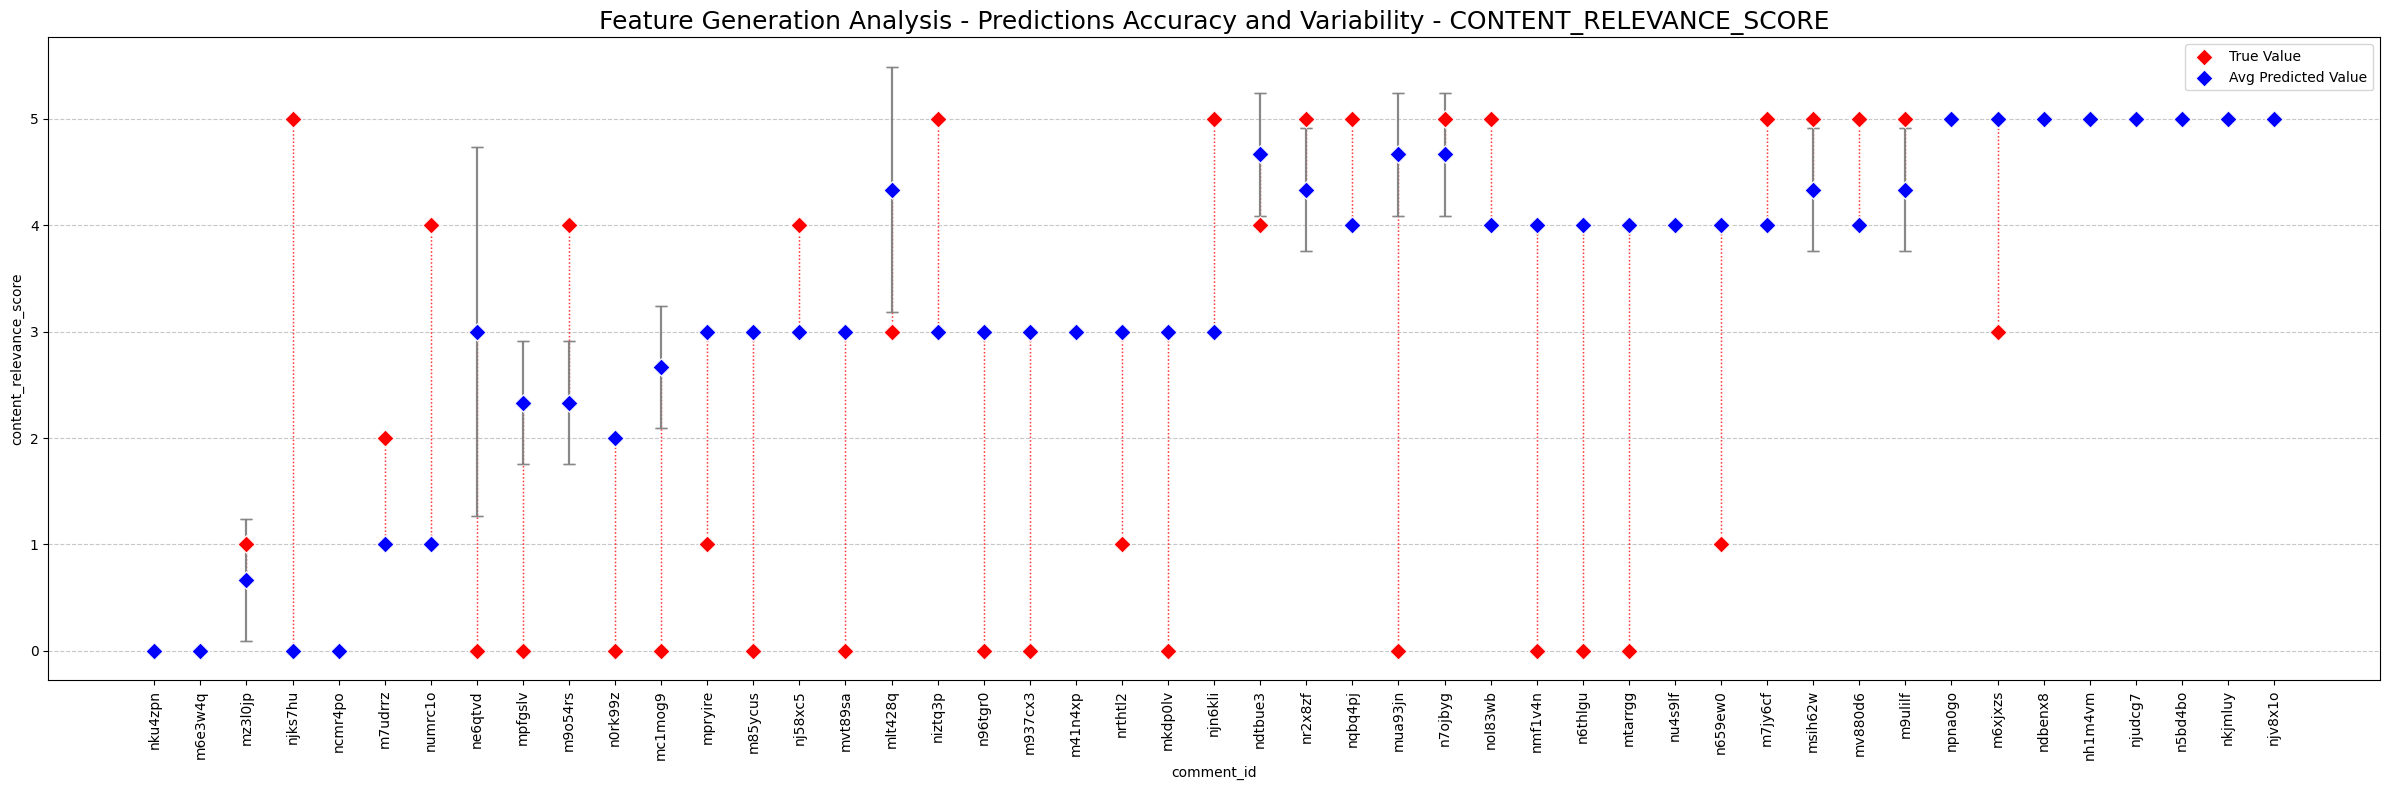

In [67]:
plt.show()

plt.figure(figsize=(24, 8))

# C. "Ground Truth" (El valor real - PUNTO ROJO)
sns.scatterplot(
    data=df_plot,
    x="comment_id",
    y=feature_name,
    color="red",
    s=75,            # Tamaño grande
    marker="D",       # Forma de diamante
    label="True Value",
    zorder=10         # Para que aparezca encima de todo
)

plt.errorbar(
    x=df_plot["comment_id"],             # Misma X
    y=df_plot["predicted_values_mean"],  # Misma Y (centro de la barra)
    yerr=df_plot["predicted_values_std"],# <--- AQUÍ VA LA LONGITUD DE LA BARRA (STD)
    fmt='none',      # 'none' significa: "no dibujes puntos, solo las líneas"
    ecolor='gray',   # Color de la barra (gris para no distraer)
    elinewidth=1.5,  # Grosor de la línea
    capsize=4,       # "Topes" horizontales en los extremos de la barra
    alpha=0.6,       # Transparencia
    zorder=5         # Nivel de capa (detrás de los puntos del scatter)
)

sns.scatterplot(
    data=df_plot,
    x="comment_id",
    y="predicted_values_mean",
    color="blue",
    s=75,            # Tamaño grande
    marker="D",       # Forma de diamante
    label="Avg Predicted Value",
    zorder=10         # Para que aparezca encima de todo
)

plt.vlines(
    x=df_plot["comment_id"],
    ymin=df_plot[feature_name],
    ymax=df_plot["predicted_values_mean"],
    colors='red',
    linestyles='dotted',
    alpha=0.4,
    linewidth=1,
    label='Residual Error'
)

plt.title(f"Feature Generation Analysis - Predictions Accuracy and Variability - {feature_name.upper()}", fontsize=18)
plt.xticks(rotation=90, fontsize=10) # Rotar etiquetas 90 grados
plt.grid(axis='y', linestyle='--', alpha=0.7) # Rejilla horizontal para ver mejor los niveles
plt.tight_layout()

plt.show()